### Architecture Diagram

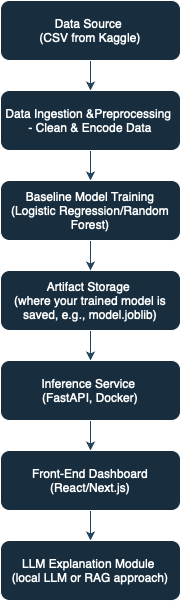

# Exploratory Data Analysis 
Predict behaviour to retain customers. You can analyze all rlevant cusotmer data and develop focused customre retention programs
Each row represents a customer, each column contains customer's attributes described on the column Metadata.

The Data set includes information about:
* Customer who left within the last month - the column is clled Churn.
* Services that each customer has signed up for - phoine, multiple lines, internet, online security, online backup, device protection, tech support, and straming TV and movies
* Customer account information - how long they've been a customer, contract, payment method, paperless billing, monthly charges, and total charges.
* Demographic info about customers - gender, age, range, and if they have partners and dependents

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the plots to display inline
%matplotlib inline
sns.set(style="whitegrid")

In [10]:
# Load Dataset
data_path = "../../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

# Display the first few rows to get a glimpse of the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Check the shape of the dataset
print("Dataset shape:", df.shape)

# Get detailed info on the dataset (data types, non-null counts)
df.info()

# Display basic statistics for numerical columns, summary statisctics useful for spotting outliers
df.describe()

Dataset shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
#  Count the missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
# If there are any missing values, note which columns are affected. We can decide later if we need to impute, drop, or further analyze these columns.

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


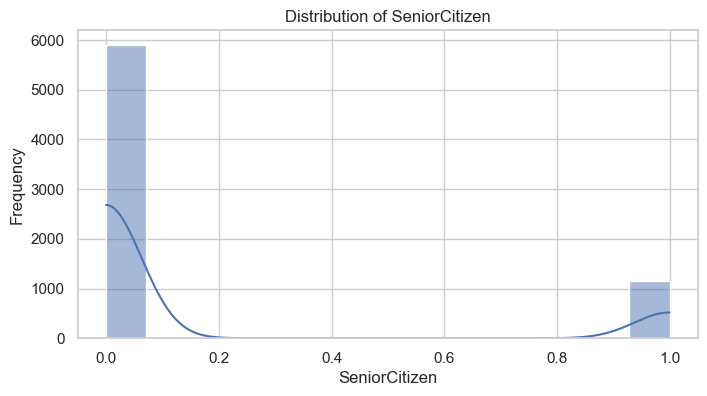

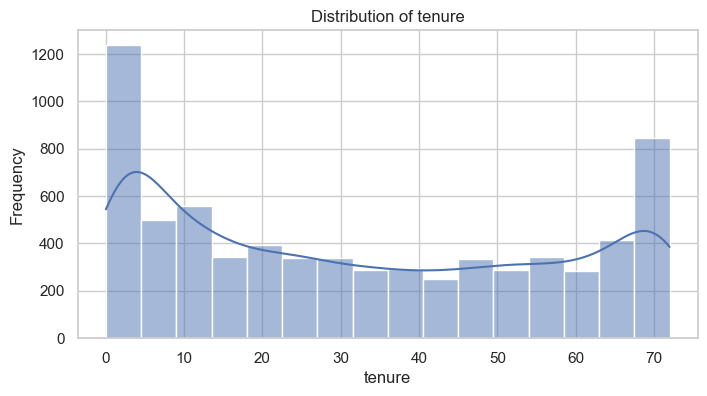

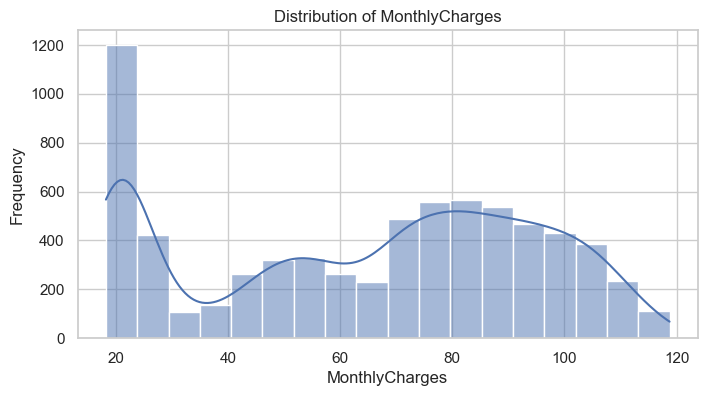

In [14]:
# Exploratory Visualization

# Identify numerical columns; looks through the entire spreadsheet and picks out only the columns that have integer or decimal (float) values.
num_features = df.select_dtypes(include=["int64", "float64"]).columns

#  Plot distributinos for each numerical feature, KDE(Kernel Density Estimate) line. 
for col in num_features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde= True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    
# The loop generates a histogram (with a KDE overlay) for each numeric feature. This is useful for detecting skewness, outliers, or unusual patterns.
    
# Interpreting the Plots
# Senior Citizen: 
# You'll likely see two big "chunks": one at 0(most people are not senior citizens) and a smaller one at 1 (some are senior citizens). 
# The KDE curve may look a bit odd here because its basically a yes/no column

# Tenure:
# This shows how  many months a customer has stayed.
# You might see a spike at the beginning (people who just joined or stayed a short time) and another spike at the end (long-term customers). 
# This distribution can tell you if ther's a sweet spot where people tend to drop off.

# MonthlyCharges:
# Shows how much people are paying per month. 
# You might see it skew to the lower end (many customers paying arounf $20-$30) and a tail stretching toward $120 for those on more expensive plans. 


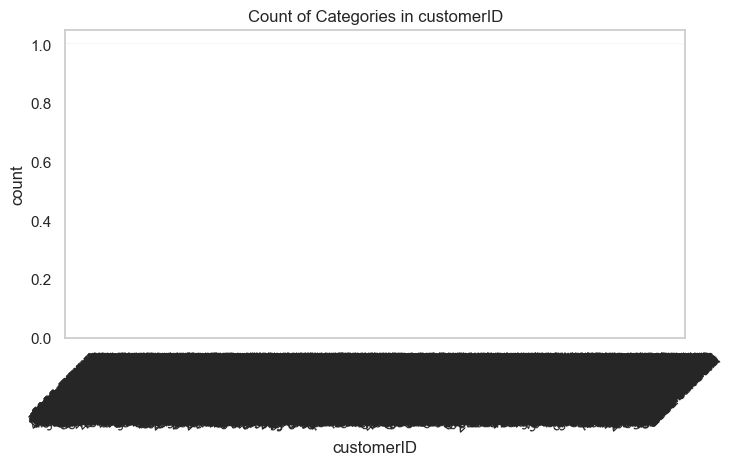

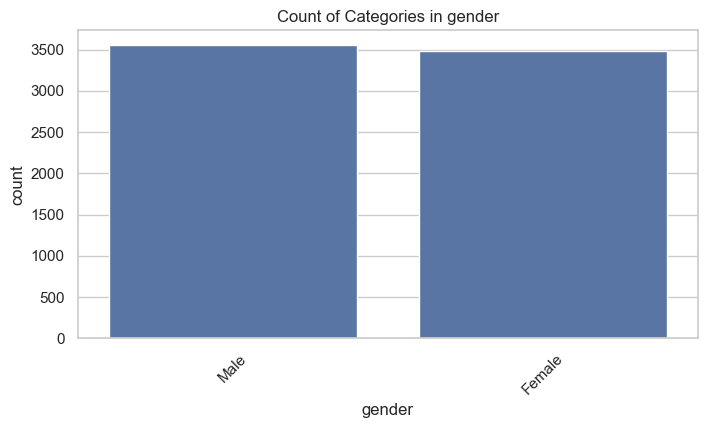

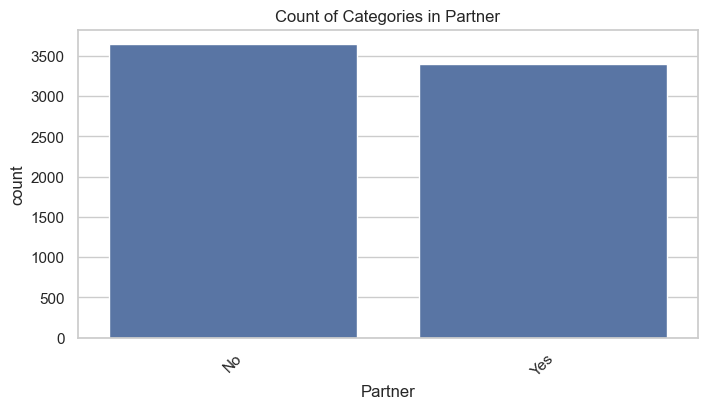

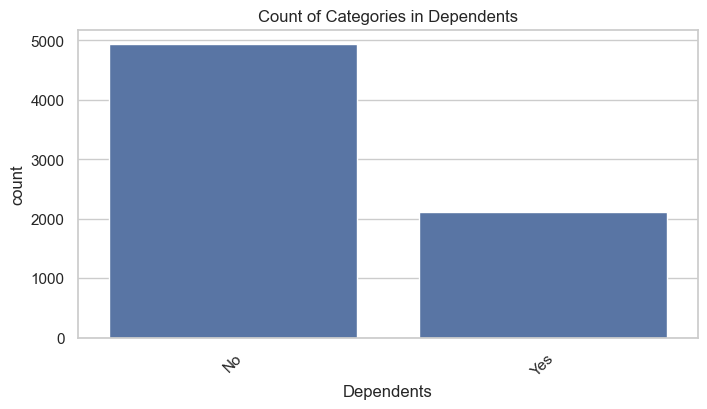

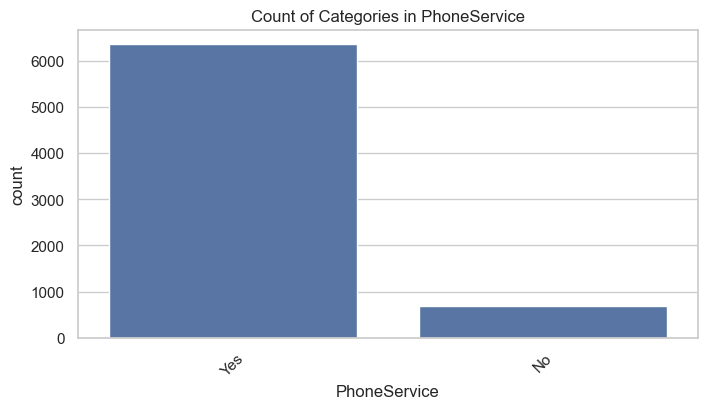

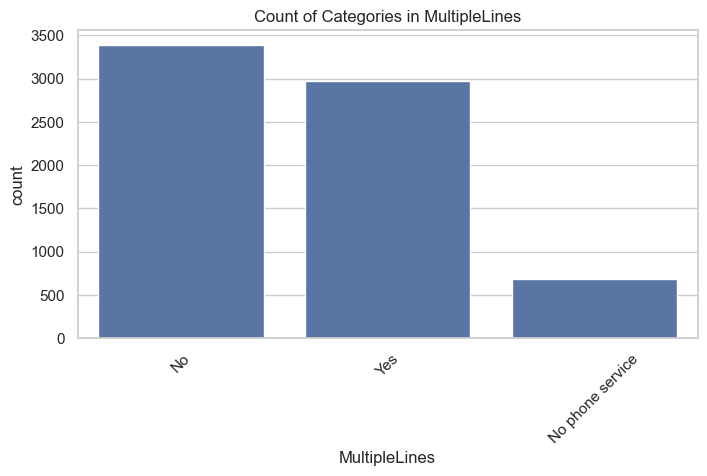

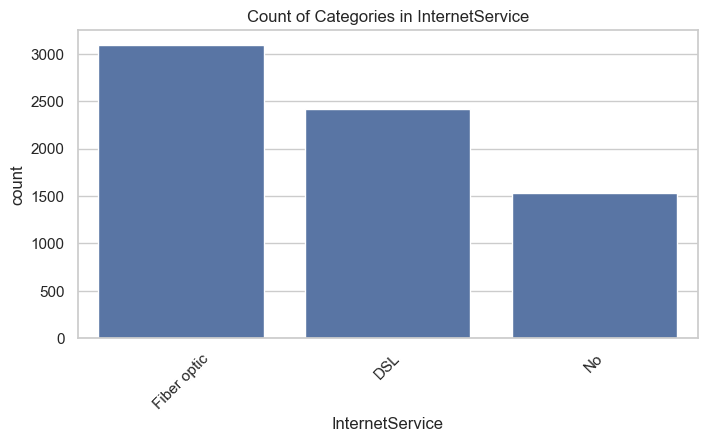

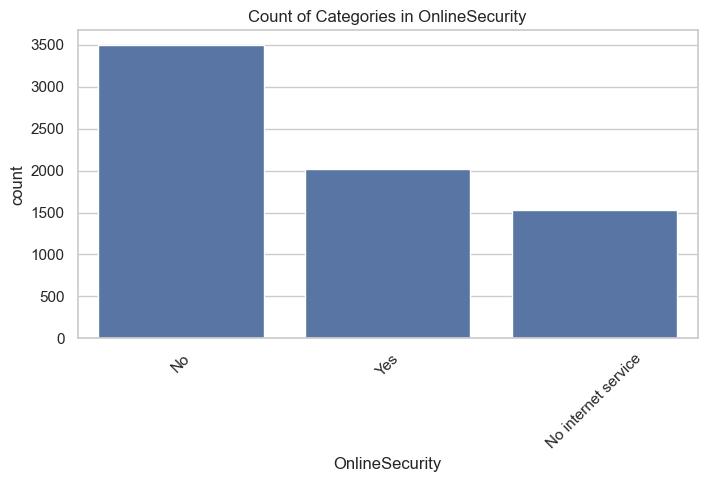

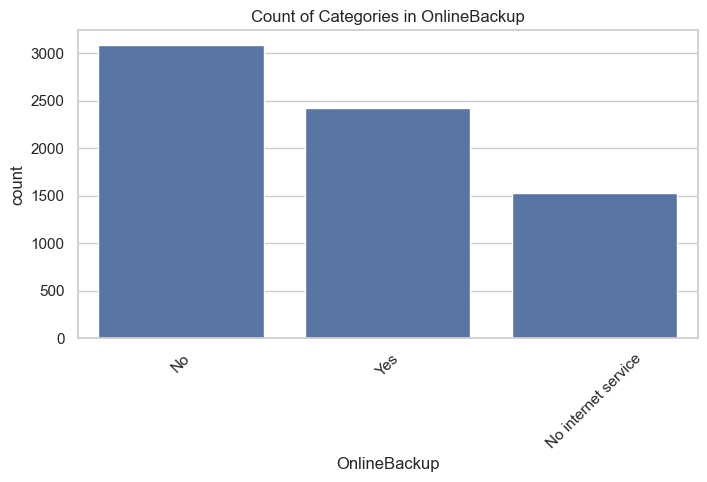

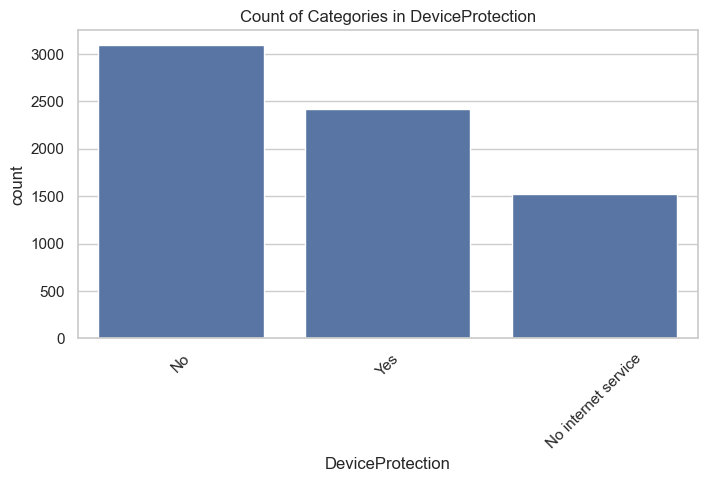

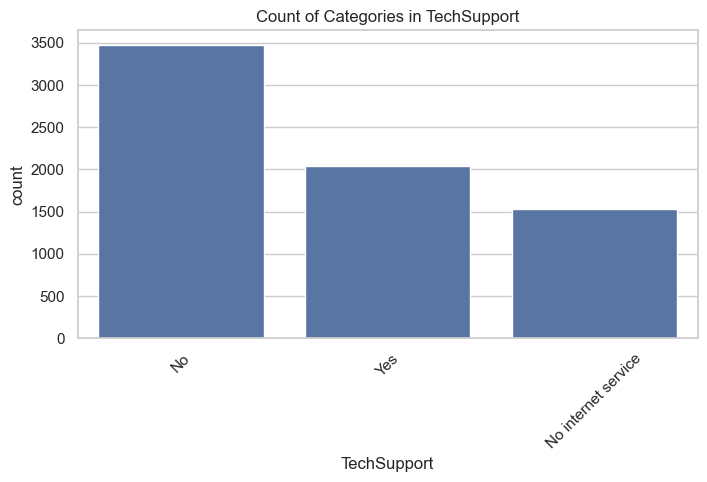

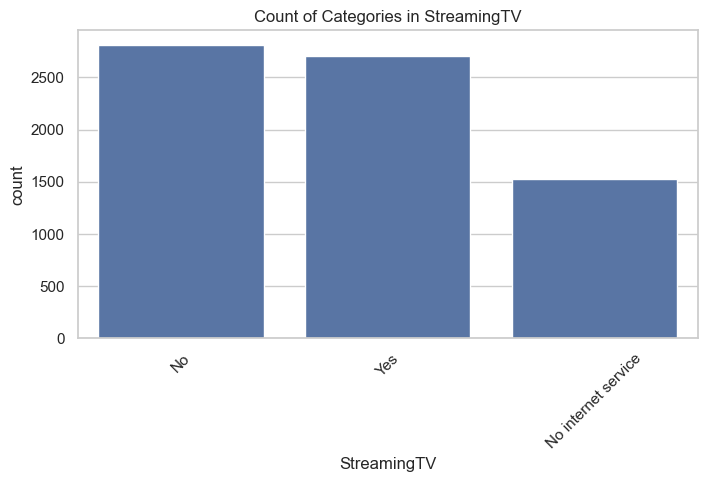

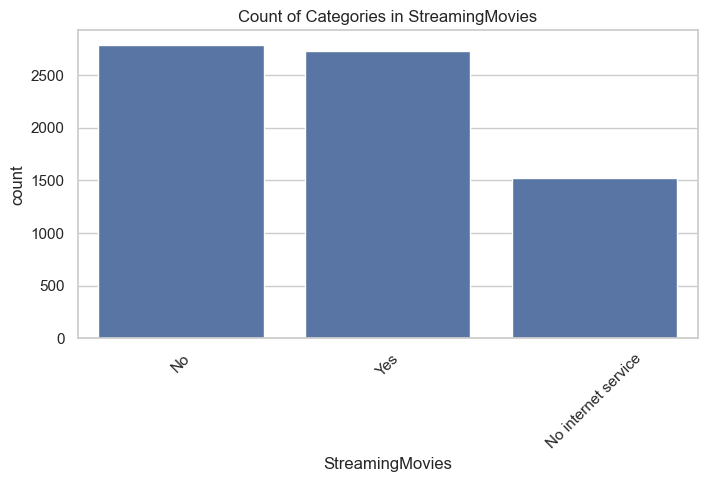

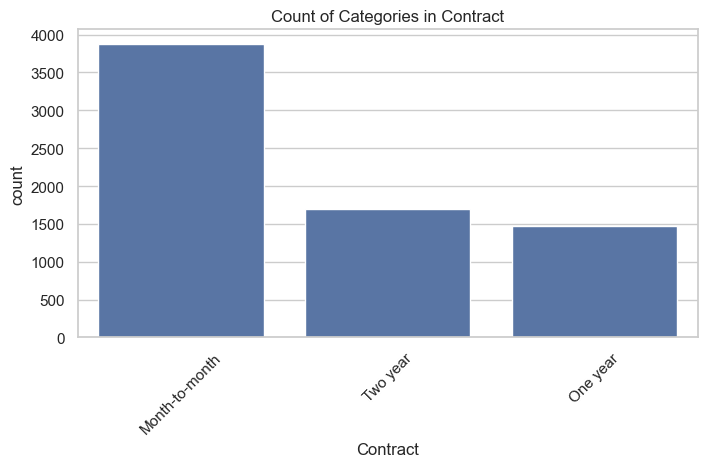

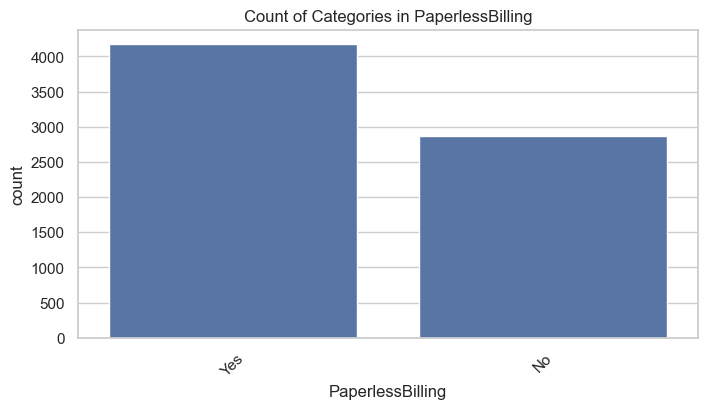

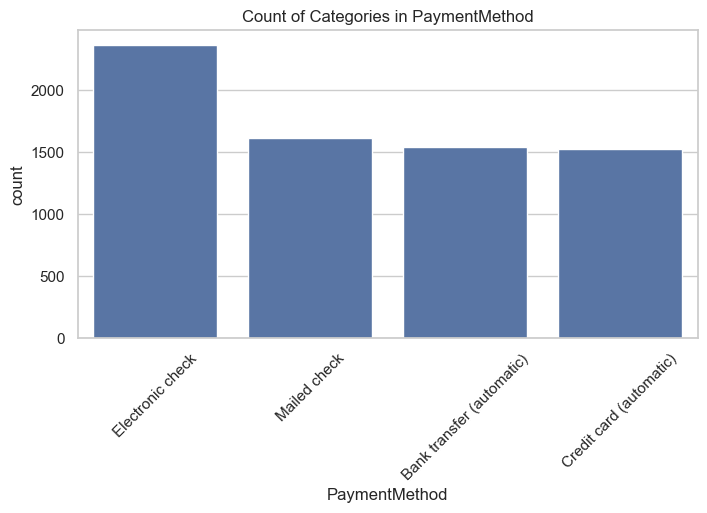

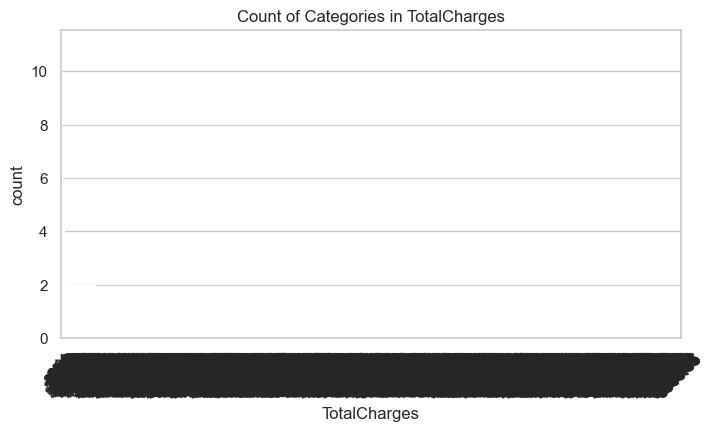

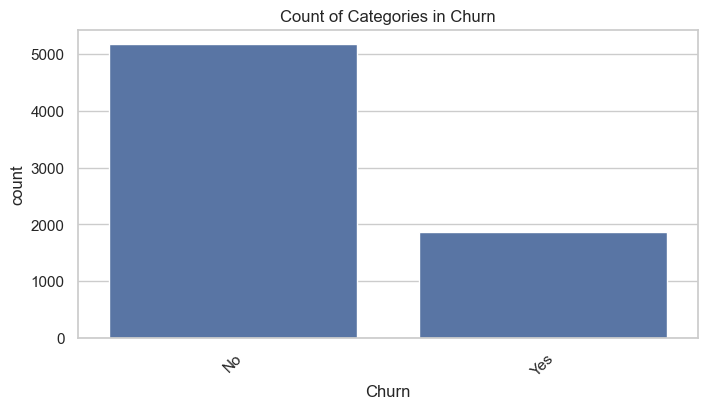

In [15]:
# Analysis of Categorical features using count plots:
# Identify categorical columns
cat_features = df.select_dtypes(include=["object"]).columns

# Plot count for each categorical feature
for col in cat_features:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Count of Categories in {col}')
    plt.xticks(rotation=45)
    plt.show()

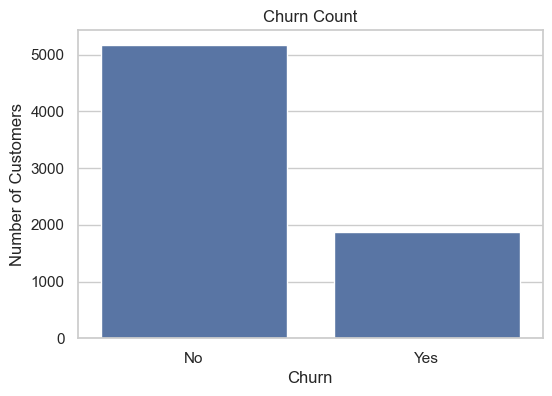

In [16]:
# Churn Rate Analysis:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", order=df["Churn"].value_counts().index)
plt.title("Churn Count")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# This bar chart is showing how many customers said "No" (they did not leave the company) versus "Yes" (they did leave).
# Most Customers stayed with the service - and the "Yes" bar is shorter, showing fewer people canceled.

# The dataset is imbalanced: there are many more "No" (non-churners) than "Yes" (churners). That's common situation in churn data.
# It just means we have to be careful when building our models later, because manu machine learning algorithms can struggle if one group (like "No" Churn) is way bigger than the other.


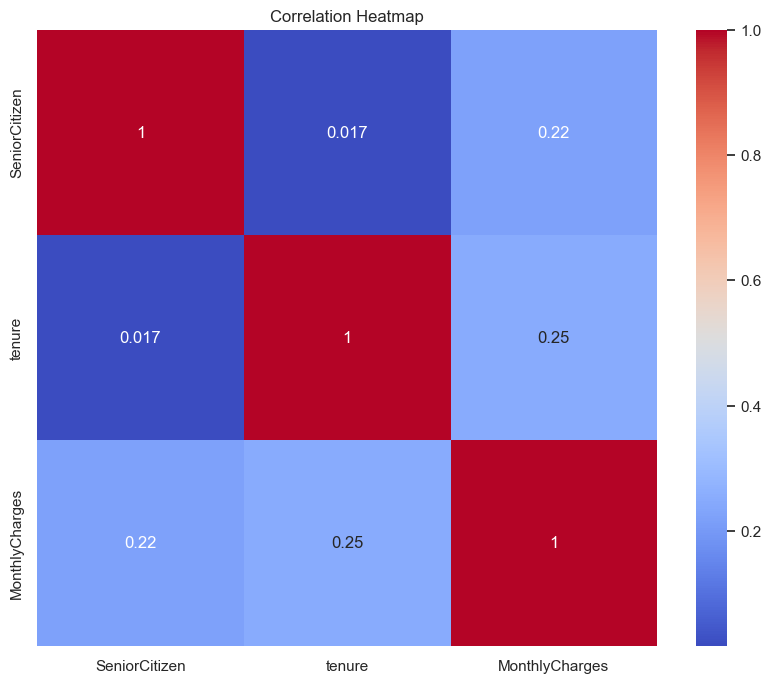

In [17]:
# Correlation Analysis: Correlation insights can help in feature selection and understanding multicollinearity issues.
plt.figure(figsize=(10, 8))
corr_matrix = df[num_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Reading the Heatmap
What the Colors Mean 
* The Heatmap uses a color scale from blue (low correlation) to red (high correlation), with white in the middle representing moderate values.
* The diagonal is always 1 (dark red) because each feature is perfectly correlated with itself.

Correlation Values
A correlation coefficient (show in each cell) can range from -1 to 1:
* +1 = Perfect positive correlation (if one feature goes up, the other also goes up in a perfectly linear way).
* 0 = No linear relationship.
* -1 = Perfect negative correlation (if one goes up, the other goes down).

Observations 
* SeniorCitizen & MonthlyCharges: 0.22 (slightly positive). This suggests senior citizens pay a bit more on average, but relationship isn't very strong.
* Tenure & MonthlyCharges: 0.25 (slightly positive). Customers who have been around longer might be paying somewhat more, but again, not a strong correlation.
* SeniorCitizen & MonthlyCharges have a correlation of 0.017, which is extremely close to 0. This means there's almost no linear relationship between whether someone is a senior citizen and how long they've been a customer.


### How it helps in Feature Selection

Identify Redundant Features:
* If two features had a very high correlation (say, above 0.8), you might consider dropping or combining one of them. 
* High correlation can lead to redundancy, which sometimes confuses certain ml algos (this is called multicollinearity)

Spot Potential Predictors:
* If a feature is highly correlated with your target variable (in this case, churn), it might be a strong predictor. 
Note: your churn is likely, categorical, so you'd need to convert it to a numeric representation or use a different statistical measure to see its correlation with these numeric features.
* Even moderate correlations (like 0.25) can be useful signals in a predictive model, though thy're not super strong on their own.

Plan Further Analysis
* Weak correlations (near 0) dont automatically mean a feature is unimportant, but they do sugggest that there's no strong linear relationship. There may be other (non-linear) patterns.
* If you see no correlation and you suspect no other relationships, you might deprioritize that feature in you model.


Why this matters for Churn Predictions, when building your churn model:
Avoid Overfitting
* Highly correlated features can cause your model to overfit or give undue importance to redundant information.
Model Simplicity
* Reducing features that bring no predictive value or are duplicates of others (in a linear sense) can make your model faster and easier to interpret.
Feature Engineering
* If you notice moderate correlation, you might combine or transform features (e.g., create a new feature that captures the relationship more directly)

### In a Nutshell
The correlation heatmap gives you a snapshot of how your numeric features realte to each other.
* Low correlations mean those features behave independently.
* High correlations might mean redundancy or the need for feature engineering.
* Moderate correlations could still be helpful in predicting churn, but you'll want to confirm with further modelling or other statistical tests.